In [38]:
from google.colab import drive
drive.mount('/content/drive')  # Mount Google Drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
import os
import numpy as np
import cv2
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Define paths to drought and non-drought folders
drought_path = '/content/drive/My Drive/Dataset/Drought/'
nondrought_path = '/content/drive/My Drive/Dataset/Nondrought/'

# Resize images to 128x128
def load_and_preprocess_images(image_folder, size=(128, 128)):
    images = []
    labels = []

    for label, folder in enumerate([drought_path, nondrought_path]):
        folder_path = drought_path if label == 0 else nondrought_path
        for image_name in os.listdir(folder_path):
            img = cv2.imread(os.path.join(folder_path, image_name))
            img_resized = cv2.resize(img, size)
            img_normalized = img_resized / 255.0  # Normalize to [0,1]
            images.append(img_normalized)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load and preprocess images
images, labels = load_and_preprocess_images(drought_path)
print(f'Loaded {images.shape[0]} images')

Loaded 200 images


In [40]:
def color_histograms(images, bins=16):
    hist_features = []
    for img in images:
        # Check if image is grayscale and convert it to BGR
        if len(img.shape) == 2:  # If grayscale
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        elif len(img.shape) != 3:
            print("Error: Image does not have 3 channels.")
            continue

        # Check if image is in valid format
        print(f"Processing image with shape: {img.shape}")

        # Calculate histogram for each channel (R, G, B)
        hist = cv2.calcHist([img], [0, 1, 2], None, [bins, bins, bins], [0, 256, 0, 256, 0, 256])
        hist = hist.flatten()  # Flatten the histogram to 1D
        hist_features.append(hist)

    return np.array(hist_features)

In [41]:
# calculate color statistics (mean, standard deviation for each channel)
def color_statistics(images):
    means = np.mean(images, axis=(1, 2))  # Mean across width and height
    stds = np.std(images, axis=(1, 2))    # Standard deviation across width and height
    return np.hstack([means, stds])  # Combine mean and std into a single vector

# Extract color statistics from images
color_stats = color_statistics(images)
print(f'Color statistics extracted for {color_stats.shape[0]} images')

Color statistics extracted for 200 images


In [42]:
# calculate color histograms (RGB or HSV)
def color_histograms(images, bins=16):
    hist_features = []
    for img in images:
        # Check if image is grayscale and convert it to BGR
        if len(img.shape) == 2:  # If grayscale
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

        # Ensure the image is of type np.uint8 (8-bit unsigned integer)
        if img.dtype != np.uint8:
            print(f"Converting image dtype from {img.dtype} to np.uint8")
            img = np.uint8(img)

        # Calculate histogram for each channel (R, G, B)
        hist = cv2.calcHist([img], [0, 1, 2], None, [bins, bins, bins], [0, 256, 0, 256, 0, 256])
        hist = hist.flatten()  # Flatten the histogram to 1D
        hist_features.append(hist)

    return np.array(hist_features)

# Extract color histograms from images
color_hist = color_histograms(images)
print(f'Color histograms extracted for {color_hist.shape[0]} images')

Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to np.uint8
Converting image dtype from float64 to n

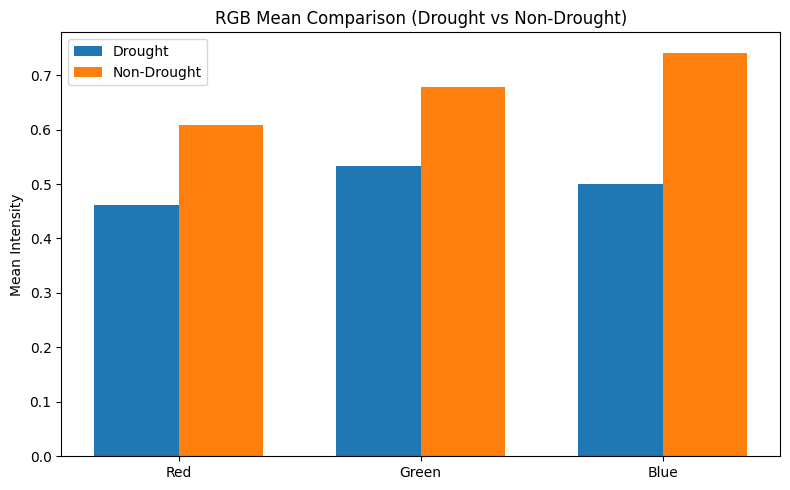

In [43]:
import numpy as np
import matplotlib.pyplot as plt

# Separate drought and non-drought
drought_features = color_stats[labels == 0]
nondrought_features = color_stats[labels == 1]

# Compute mean RGB values
drought_mean = drought_features.mean(axis=0)[:3]
nondrought_mean = nondrought_features.mean(axis=0)[:3]

channels = ['Red', 'Green', 'Blue']
x = np.arange(len(channels))
width = 0.35

plt.figure(figsize=(8,5))
plt.bar(x - width/2, drought_mean, width, label='Drought')
plt.bar(x + width/2, nondrought_mean, width, label='Non-Drought')

plt.xticks(x, channels)
plt.ylabel('Mean Intensity')
plt.title('RGB Mean Comparison (Drought vs Non-Drought)')
plt.legend()
plt.tight_layout()

plt.savefig('rgb_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [44]:
from skimage.feature import hog
import numpy as np
import cv2

def extract_features(images):
    features = []

    for img in images:
        # Fix datatype issue
        if img.dtype != np.uint8:
            img = (img * 255).astype(np.uint8)

        # Handle grayscale vs color
        if len(img.shape) == 2:
            gray = img
        else:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        hog_feat = hog(
            gray,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            feature_vector=True
        )

        features.append(hog_feat)

    return np.array(features)

In [45]:
# Step 1: Extract HOG features
X = extract_features(images)

# Step 2: Convert labels to numpy array
y = np.array(labels)

# Step 3: Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [47]:
linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

rbf_model = SVC(kernel='rbf', C=10)
rbf_model.fit(X_train, y_train)

SVC(C=10)

[[ 9 12]
 [ 4 15]]
              precision    recall  f1-score   support

           0       0.69      0.43      0.53        21
           1       0.56      0.79      0.65        19

    accuracy                           0.60        40
   macro avg       0.62      0.61      0.59        40
weighted avg       0.63      0.60      0.59        40



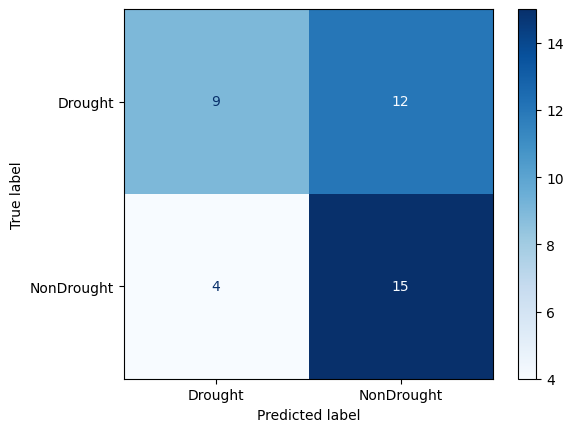

In [48]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rbf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred),
                              display_labels=["Drought", "NonDrought"])
disp.plot(cmap="Blues")
plt.show()